# Wstepna analiza danych o ruchu w Warszawie

Notebook wczytuje jedna z rozwazanych ramek z katalogu `data` i wykonuje podstawowe EDA: opis struktury danych, zakres czasowy, braki, duplikaty, rozklady predkosci oraz pierwsze agregacje po czasie i segmentach.

Na start uzywamy pliku `data/data_2024-11-01.csv`. W razie potrzeby wystarczy zmienic zmienna `DATA_FILE` w pierwszej komorce kodu.

## 1. Import bibliotek i wybor pliku

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "data_2024-11-01.csv"

DATA_FILE

WindowsPath('data/data_2024-11-01.csv')

## 2. Wczytanie danych

Pliki `data_YYYY-MM-DD.csv` zawieraja predkosci na odcinkach drogowych. W pierwszym pliku kolumny to:

- `segmnet_id` - identyfikator segmentu; nazwa wyglada na literowke od `segment_id`,
- `wkt` - geometria odcinka w formacie WKT `LINESTRING(lon lat, ...)`,
- `time` - znacznik czasu pomiaru,
- `avg_speed` - srednia predkosc na segmencie.

In [2]:
df_raw = pd.read_csv(DATA_FILE)
df_raw.head()

,segmnet_id,wkt,time,avg_speed
0,7347105,"LINESTRING(21.02681 52.298027,21.028872 52.298...",2024-11-01 00:00:00.000000,52
1,21705026,"LINESTRING(21.03263 52.299625,21.03293 52.2997)",2024-11-01 00:00:00.000000,49
2,19332729,"LINESTRING(21.062801 52.30707,21.061604 52.306...",2024-11-01 00:00:00.000000,50
3,24669203,"LINESTRING(21.01367 52.297817,21.013054 52.298...",2024-11-01 00:00:00.000000,31
4,19332910,"LINESTRING(21.085352 52.30732,21.087095 52.30732)",2024-11-01 00:00:00.000000,50


In [3]:
df_raw.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66130 entries, 0 to 66129
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   segmnet_id  66130 non-null  int64 
 1   wkt         66130 non-null  object
 2   time        66130 non-null  object
 3   avg_speed   66130 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 15.4 MB


## 3. Porzadkowanie typow

Tworzymy robocza kopie ramki, parsujemy czas i dodajemy podstawowe cechy czasowe. Zostawiamy oryginalna nazwe `segmnet_id`, ale tworzymy tez wygodniejszy alias `segment_id`.

In [4]:
df = df_raw.copy()
df["time"] = pd.to_datetime(df["time"])
df = df.rename(columns={"segmnet_id": "segment_id"})

df["date"] = df["time"].dt.date
df["hour"] = df["time"].dt.hour
df["minute"] = df["time"].dt.minute
df["time_of_day"] = df["time"].dt.strftime("%H:%M")

df.head()

,segment_id,wkt,time,avg_speed,date,hour,minute,time_of_day
0,7347105,"LINESTRING(21.02681 52.298027,21.028872 52.298...",2024-11-01,52,2024-11-01,0,0,00:00
1,21705026,"LINESTRING(21.03263 52.299625,21.03293 52.2997)",2024-11-01,49,2024-11-01,0,0,00:00
2,19332729,"LINESTRING(21.062801 52.30707,21.061604 52.306...",2024-11-01,50,2024-11-01,0,0,00:00
3,24669203,"LINESTRING(21.01367 52.297817,21.013054 52.298...",2024-11-01,31,2024-11-01,0,0,00:00
4,19332910,"LINESTRING(21.085352 52.30732,21.087095 52.30732)",2024-11-01,50,2024-11-01,0,0,00:00


## 4. Szybki opis ramki

In [5]:
summary = pd.Series({
    "liczba_wierszy": len(df),
    "liczba_kolumn": df.shape[1],
    "liczba_segmentow": df["segment_id"].nunique(),
    "liczba_geometrii_wkt": df["wkt"].nunique(),
    "liczba_znacznikow_czasu": df["time"].nunique(),
    "czas_od": df["time"].min(),
    "czas_do": df["time"].max(),
    "srednia_predkosc": df["avg_speed"].mean(),
    "mediana_predkosci": df["avg_speed"].median(),
    "min_predkosc": df["avg_speed"].min(),
    "max_predkosc": df["avg_speed"].max(),
})

summary

liczba_wierszy                           66130
liczba_kolumn                                8
liczba_segmentow                          2584
liczba_geometrii_wkt                      2584
liczba_znacznikow_czasu                     75
czas_od                    2024-11-01 00:00:00
czas_do                    2024-11-01 23:00:00
srednia_predkosc                     33.330561
mediana_predkosci                         36.0
min_predkosc                                 0
max_predkosc                               124
dtype: object

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
segment_id,66130.0,NaN,NaN,NaN,19159947.648798,9556.0,16883726.0,21087814.0,23333177.0,26407396.0,6207542.566162
wkt,66130,2584,"LINESTRING(21.02681 52.298027,21.028872 52.298...",75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,66130,NaN,NaN,NaN,2024-11-01 13:10:21.684560640,2024-11-01 00:00:00,2024-11-01 09:15:00,2024-11-01 13:15:00,2024-11-01 17:30:00,2024-11-01 23:00:00,NaN
avg_speed,66130.0,NaN,NaN,NaN,33.330561,0.0,20.0,36.0,47.0,124.0,16.883429
date,66130,1,2024-11-01,66130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,66130.0,NaN,NaN,NaN,12.829245,0.0,9.0,13.0,17.0,23.0,5.415741
minute,66130.0,NaN,NaN,NaN,20.606684,0.0,0.0,15.0,30.0,45.0,17.239872
time_of_day,66130,75,11:45,1067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Jakosc danych

Sprawdzamy braki, duplikaty i nietypowe wartosci predkosci. W danych ruchu wartosc `0` moze oznaczac realny postoj/korek, ale moze tez byc artefaktem, wiec na razie tylko ja oznaczamy.

In [7]:
quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_share": df.isna().mean(),
    "unique_count": df.nunique(dropna=True),
    "dtype": df.dtypes.astype(str),
})

quality

,missing_count,missing_share,unique_count,dtype
segment_id,0,0.0,2584,int64
wkt,0,0.0,2584,object
time,0,0.0,75,datetime64[ns]
avg_speed,0,0.0,92,int64
date,0,0.0,1,object
hour,0,0.0,24,int32
minute,0,0.0,4,int32
time_of_day,0,0.0,75,object


In [8]:
duplicate_rows = df.duplicated().sum()
duplicate_segment_time = df.duplicated(subset=["segment_id", "time"]).sum()

pd.Series({
    "duplikaty_pelnych_wierszy": duplicate_rows,
    "duplikaty_segment_czas": duplicate_segment_time,
    "wiersze_z_predkoscia_0": (df["avg_speed"] == 0).sum(),
    "udzial_predkosci_0": (df["avg_speed"] == 0).mean(),
    "wiersze_z_predkoscia_pow_100": (df["avg_speed"] > 100).sum(),
})

duplikaty_pelnych_wierszy         0.00000
duplikaty_segment_czas            0.00000
wiersze_z_predkoscia_0          984.00000
udzial_predkosci_0                0.01488
wiersze_z_predkoscia_pow_100      3.00000
dtype: float64

## 6. Rozklad predkosci

In [9]:
df["avg_speed"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    66130.000000
mean        33.330561
std         16.883429
min          0.000000
1%           0.000000
5%           3.000000
10%          8.000000
25%         20.000000
50%         36.000000
75%         47.000000
90%         53.000000
95%         56.000000
99%         63.000000
max        124.000000
Name: avg_speed, dtype: float64

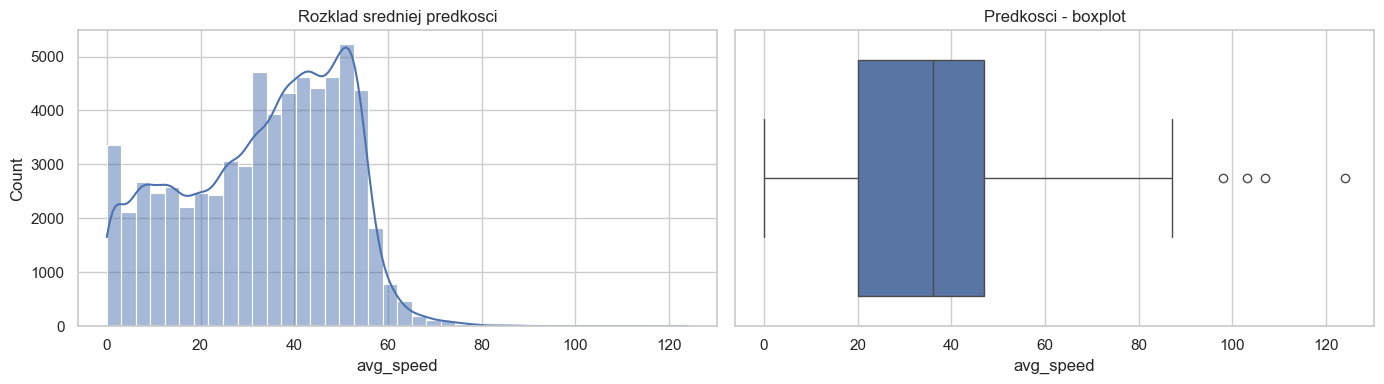

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["avg_speed"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Rozklad sredniej predkosci")
axes[0].set_xlabel("avg_speed")

sns.boxplot(x=df["avg_speed"], ax=axes[1])
axes[1].set_title("Predkosci - boxplot")
axes[1].set_xlabel("avg_speed")

plt.tight_layout()

## 7. Zmiennosc w czasie

Agregujemy predkosci po znaczniku czasu, zeby zobaczyc rytm dnia i ewentualne spadki predkosci w godzinach szczytu.

In [11]:
time_stats = (
    df.groupby("time")
    .agg(
        avg_speed_mean=("avg_speed", "mean"),
        avg_speed_median=("avg_speed", "median"),
        avg_speed_q10=("avg_speed", lambda s: s.quantile(0.10)),
        avg_speed_q90=("avg_speed", lambda s: s.quantile(0.90)),
        segments_count=("segment_id", "nunique"),
    )
    .reset_index()
)

time_stats.head()

,time,avg_speed_mean,avg_speed_median,avg_speed_q10,avg_speed_q90,segments_count
0,2024-11-01 00:00:00,32.932153,35.0,7.0,52.0,1017
1,2024-11-01 01:00:00,35.138116,38.0,10.0,53.0,934
2,2024-11-01 02:00:00,35.004479,38.0,10.0,52.0,893
3,2024-11-01 03:00:00,36.760719,42.0,10.0,52.0,723
4,2024-11-01 04:00:00,38.165714,43.0,14.0,53.0,700


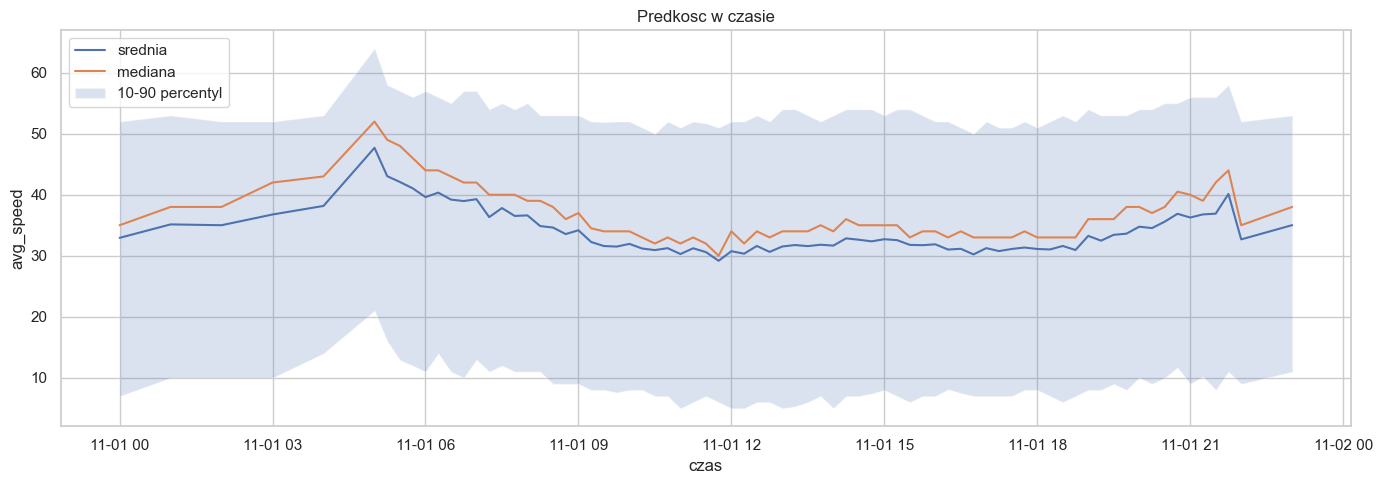

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(time_stats["time"], time_stats["avg_speed_mean"], label="srednia")
plt.plot(time_stats["time"], time_stats["avg_speed_median"], label="mediana")
plt.fill_between(
    time_stats["time"],
    time_stats["avg_speed_q10"],
    time_stats["avg_speed_q90"],
    alpha=0.2,
    label="10-90 percentyl",
)
plt.title("Predkosc w czasie")
plt.xlabel("czas")
plt.ylabel("avg_speed")
plt.legend()
plt.tight_layout()

In [13]:
hourly_stats = (
    df.groupby("hour")
    .agg(
        avg_speed_mean=("avg_speed", "mean"),
        avg_speed_median=("avg_speed", "median"),
        observations=("avg_speed", "size"),
        segments_count=("segment_id", "nunique"),
    )
    .reset_index()
)

hourly_stats

,hour,avg_speed_mean,avg_speed_median,observations,segments_count
0,0,32.932153,35.0,1017,1017
1,1,35.138116,38.0,934,934
2,2,35.004479,38.0,893,893
3,3,36.760719,42.0,723,723
4,4,38.165714,43.0,700,700
5,5,43.024434,49.0,1678,724
6,6,39.506494,43.0,2464,956
7,7,37.401487,41.0,2959,1078
8,8,34.839922,38.0,3567,1287
9,9,32.334101,35.0,3906,1364


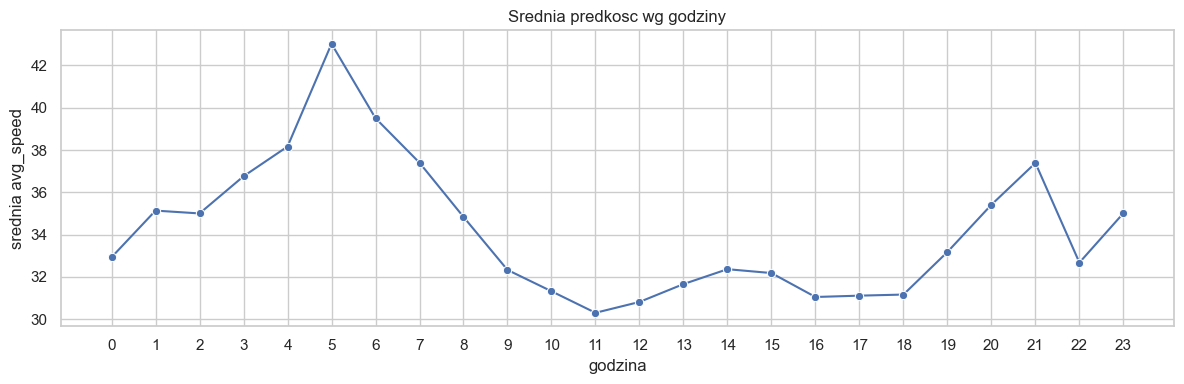

In [14]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=hourly_stats, x="hour", y="avg_speed_mean", marker="o")
plt.xticks(range(0, 24))
plt.title("Srednia predkosc wg godziny")
plt.xlabel("godzina")
plt.ylabel("srednia avg_speed")
plt.tight_layout()

## 8. Segmenty drogowe

Ponizej szukamy segmentow o najnizszych i najwyzszych typowych predkosciach oraz segmentow o najwiekszej zmiennosci.

In [15]:
segment_stats = (
    df.groupby("segment_id")
    .agg(
        observations=("avg_speed", "size"),
        avg_speed_mean=("avg_speed", "mean"),
        avg_speed_median=("avg_speed", "median"),
        avg_speed_min=("avg_speed", "min"),
        avg_speed_max=("avg_speed", "max"),
        avg_speed_std=("avg_speed", "std"),
        wkt=("wkt", "first"),
    )
    .reset_index()
)

segment_stats.head()

,segment_id,observations,avg_speed_mean,avg_speed_median,avg_speed_min,avg_speed_max,avg_speed_std,wkt
0,9556,28,19.928571,17.5,3,44,11.417753,"LINESTRING(20.925678 52.24732,20.925547 52.247..."
1,11747,53,40.264151,39.0,31,52,4.557964,"LINESTRING(21.00564 52.287865,21.005302 52.288..."
2,33302,15,44.200000,44.0,19,63,11.213512,"LINESTRING(21.003286 52.28984,21.003391 52.28973)"
3,87426,9,30.222222,30.0,23,37,5.380004,"LINESTRING(20.923073 52.24766,20.923286 52.247..."
4,104408,19,39.315789,39.0,30,53,6.489758,"LINESTRING(20.965612 52.27403,20.965261 52.274..."


In [16]:
segment_stats.sort_values("avg_speed_median").head(10)

,segment_id,observations,avg_speed_mean,avg_speed_median,avg_speed_min,avg_speed_max,avg_speed_std,wkt
277,10568055,5,0.000000,0.0,0,0,0.000000,"LINESTRING(20.893326 52.24034,20.893257 52.239..."
521,14979109,7,2.714286,0.0,0,15,5.618846,"LINESTRING(21.0598 52.309914,21.060438 52.309998)"
894,19062085,4,0.000000,0.0,0,0,0.000000,"LINESTRING(21.0598 52.309914,21.059816 52.3098..."
893,19062080,4,0.000000,0.0,0,0,0.000000,"LINESTRING(21.05982 52.309853,21.059816 52.309..."
892,18954201,1,0.000000,0.0,0,0,NaN,"LINESTRING(21.0488 52.304737,21.04885 52.30458..."
522,14979112,7,1.857143,0.0,0,12,4.488079,"LINESTRING(21.060438 52.309998,21.0598 52.309914)"
890,18948653,1,0.000000,0.0,0,0,NaN,"LINESTRING(21.029964 52.300293,21.029917 52.30..."
887,18947198,3,0.333333,0.0,0,1,0.577350,"LINESTRING(21.041878 52.303177,21.04213 52.303..."
531,15193659,1,0.000000,0.0,0,0,NaN,"LINESTRING(20.96038 52.281635,20.960533 52.28169)"
885,18947196,1,0.000000,0.0,0,0,NaN,"LINESTRING(21.042313 52.30296,21.04213 52.3032..."


In [17]:
segment_stats.sort_values("avg_speed_std", ascending=False).head(10)

,segment_id,observations,avg_speed_mean,avg_speed_median,avg_speed_min,avg_speed_max,avg_speed_std,wkt
2130,24688468,2,36.000000,36.0,6,66,42.426407,"LINESTRING(21.064869 52.31205,21.064941 52.312..."
843,18901129,17,37.647059,29.0,0,103,34.942705,"LINESTRING(20.898764 52.244884,20.899828 52.24..."
1865,22862984,3,36.000000,39.0,3,66,31.606961,"LINESTRING(20.876078 52.22726,20.876677 52.227..."
738,18159808,2,62.000000,62.0,40,84,31.112698,"LINESTRING(20.87312 52.225204,20.872358 52.224..."
490,14929780,2,34.500000,34.5,14,55,28.991378,"LINESTRING(21.051395 52.304726,21.051363 52.30..."
469,14691546,2,28.500000,28.5,8,49,28.991378,"LINESTRING(20.965862 52.27239,20.96626 52.272648)"
2489,26092859,2,20.500000,20.5,2,39,26.162951,"LINESTRING(20.886456 52.238293,20.886374 52.23..."
2386,25418208,7,23.857143,14.0,1,65,24.667310,"LINESTRING(20.99202 52.28132,20.99216 52.28116..."
199,8885947,5,28.800000,36.0,2,58,23.700211,"LINESTRING(20.97596 52.27909,20.976154 52.2790..."
252,9567161,2,43.500000,43.5,27,60,23.334524,"LINESTRING(20.870964 52.223106,20.868914 52.22..."


## 9. Prosta eksploracja geometrii WKT

Bez dodatkowych bibliotek GIS mozemy wyciagnac punkty `lon lat` z `LINESTRING` i sprawdzic przyblizony zasieg danych. To nie zastapi geometrii z `geopandas`, ale wystarcza do pierwszego sanity checku.

In [18]:
def parse_linestring_bounds(wkt: str) -> pd.Series:
    numbers = [float(x) for x in re.findall(r"-?\d+\.\d+", wkt)]
    lon = numbers[0::2]
    lat = numbers[1::2]
    return pd.Series({
        "lon_min": min(lon),
        "lon_max": max(lon),
        "lat_min": min(lat),
        "lat_max": max(lat),
        "points_count": len(lon),
    })

geometry_bounds = df[["segment_id", "wkt"]].drop_duplicates("segment_id").copy()
geometry_bounds = pd.concat(
    [geometry_bounds, geometry_bounds["wkt"].apply(parse_linestring_bounds)],
    axis=1,
)

geometry_bounds.describe().T

,count,mean,std,min,25%,50%,75%,max
segment_id,2584.0,1.936564e+07,5.813498e+06,9556.000000,1.688373e+07,2.108764e+07,2.347452e+07,2.640740e+07
lon_min,2584.0,2.098275e+01,5.853950e-02,20.862360,2.095138e+01,2.098815e+01,2.102518e+01,2.109556e+01
lon_max,2584.0,2.098365e+01,5.848831e-02,20.862562,2.095189e+01,2.098908e+01,2.102657e+01,2.109997e+01
lat_min,2584.0,5.227811e+01,2.455855e-02,52.215850,5.226125e+01,5.228185e+01,5.229860e+01,5.231509e+01
lat_max,2584.0,5.227861e+01,2.445849e-02,52.216090,5.226161e+01,5.228263e+01,5.229901e+01,5.231542e+01
points_count,2584.0,4.604489e+00,3.932935e+00,2.000000,2.000000e+00,3.000000e+00,5.000000e+00,3.800000e+01


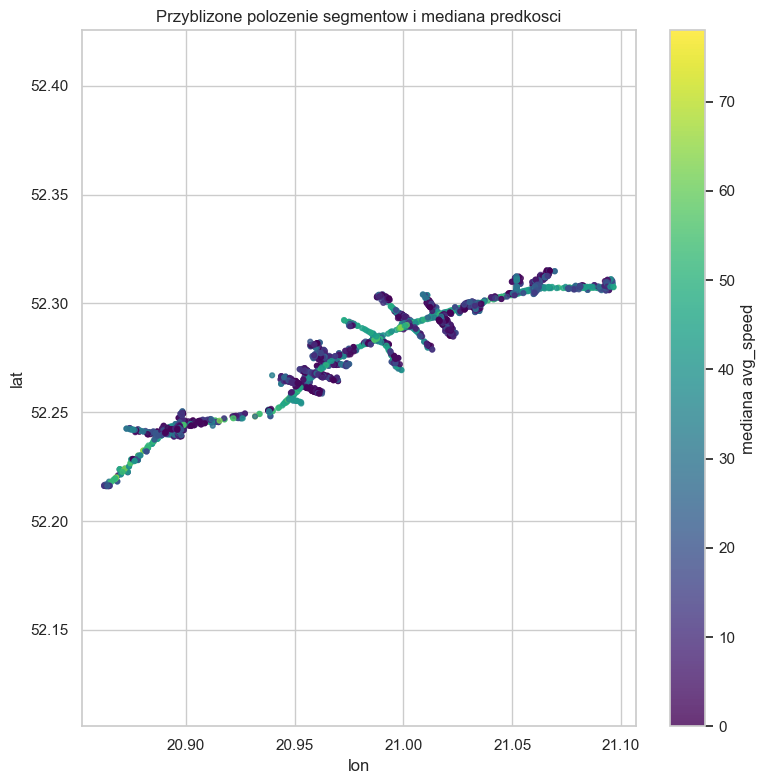

In [19]:
segment_map = segment_stats.merge(geometry_bounds, on=["segment_id", "wkt"], how="left")
segment_map["lon_center"] = (segment_map["lon_min"] + segment_map["lon_max"]) / 2
segment_map["lat_center"] = (segment_map["lat_min"] + segment_map["lat_max"]) / 2

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    segment_map["lon_center"],
    segment_map["lat_center"],
    c=segment_map["avg_speed_median"],
    s=12,
    cmap="viridis",
    alpha=0.8,
)
plt.colorbar(scatter, label="mediana avg_speed")
plt.title("Przyblizone polozenie segmentow i mediana predkosci")
plt.xlabel("lon")
plt.ylabel("lat")
plt.axis("equal")
plt.tight_layout()

## 10. Mapy segmentow i zatloczenia

Do mapowania wykorzystujemy `geopandas`, `shapely` i opcjonalnie `folium`. Najpierw zamieniamy kolumne WKT na prawdziwa geometrie, a potem laczymy geometrie ze statystykami predkosci.

Kolory sa ustawione w stylu map ruchu: zielony oznacza plynny ruch, zolty umiarkowane spowolnienie, czerwony duze spowolnienie. Poniewaz nie mamy liczby pojazdow, kolor nie jest natezeniem ruchu w sensie wolumenu, tylko przyblizeniem zatloczenia na podstawie spadku predkosci.

In [20]:
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
from shapely import wkt

traffic_cmap = LinearSegmentedColormap.from_list(
    "traffic_green_yellow_red",
    ["#1a9850", "#fee08b", "#d73027"],
)

segments_gdf = df[["segment_id", "wkt"]].drop_duplicates("segment_id").copy()
segments_gdf["geometry"] = segments_gdf["wkt"].apply(wkt.loads)
segments_gdf = gpd.GeoDataFrame(segments_gdf, geometry="geometry", crs="EPSG:4326")

segment_speed_gdf = segments_gdf.merge(segment_stats.drop(columns="wkt"), on="segment_id", how="left")

reference_speed = (
    df.groupby("segment_id")["avg_speed"]
    .quantile(0.90)
    .rename("reference_speed")
    .reset_index()
)

segment_traffic_gdf = segment_speed_gdf.merge(reference_speed, on="segment_id", how="left")
segment_traffic_gdf["daily_speed_ratio"] = (
    segment_traffic_gdf["avg_speed_median"] / segment_traffic_gdf["reference_speed"]
).replace([np.inf, -np.inf], np.nan)
segment_traffic_gdf["daily_congestion"] = (1 - segment_traffic_gdf["daily_speed_ratio"]).clip(lower=0, upper=1)

segment_traffic_gdf.head()


,segment_id,wkt,geometry,observations,avg_speed_mean,avg_speed_median,avg_speed_min,avg_speed_max,avg_speed_std,reference_speed,daily_speed_ratio,daily_congestion
0,7347105,"LINESTRING(21.02681 52.298027,21.028872 52.298...","LINESTRING (21.02681 52.29803, 21.02887 52.29861)",75,53.306667,53.0,48,61,2.701218,57.0,0.929825,0.070175
1,21705026,"LINESTRING(21.03263 52.299625,21.03293 52.2997)","LINESTRING (21.03263 52.29962, 21.03293 52.2997)",59,56.847458,55.0,30,76,8.764768,68.0,0.808824,0.191176
2,19332729,"LINESTRING(21.062801 52.30707,21.061604 52.306...","LINESTRING (21.0628 52.30707, 21.0616 52.3069,...",75,51.680000,52.0,47,56,1.508176,53.6,0.970149,0.029851
3,24669203,"LINESTRING(21.01367 52.297817,21.013054 52.298...","LINESTRING (21.01367 52.29782, 21.01305 52.2986)",58,40.000000,39.0,31,63,5.830952,47.3,0.824524,0.175476
4,19332910,"LINESTRING(21.085352 52.30732,21.087095 52.30732)","LINESTRING (21.08535 52.30732, 21.0871 52.30732)",75,55.146667,55.0,47,74,3.864927,58.6,0.938567,0.061433


In [21]:
segment_speed_gdf.total_bounds


array([20.86236 , 52.21585 , 21.099972, 52.315422])

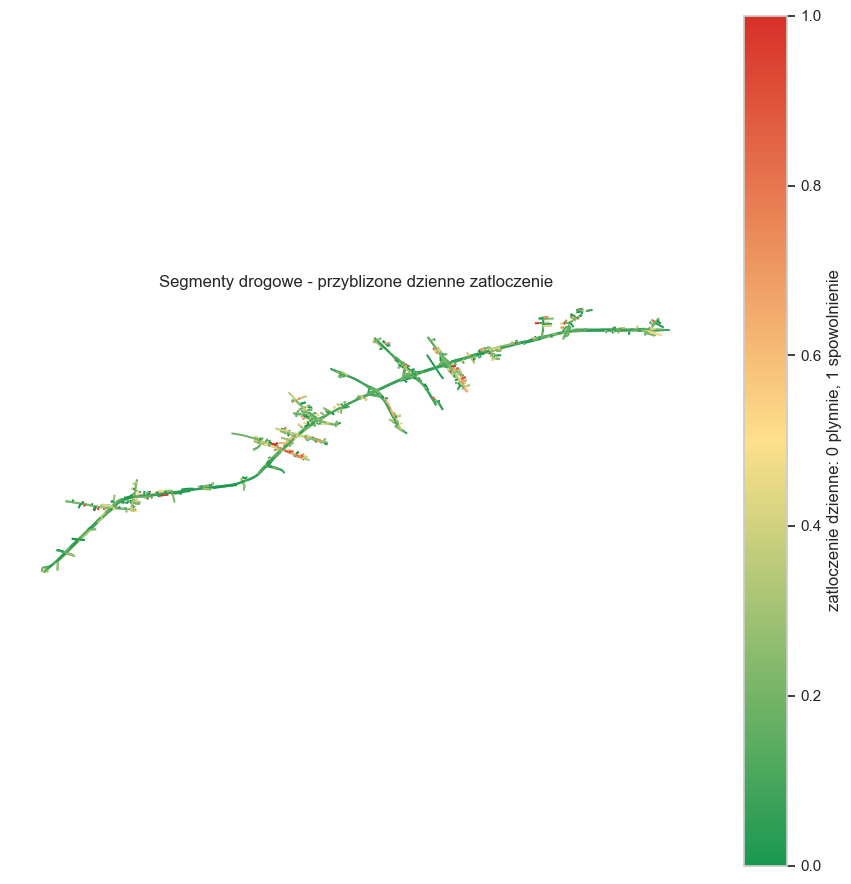

In [22]:
fig, ax = plt.subplots(figsize=(9, 9))
segment_traffic_gdf.plot(
    column="daily_congestion",
    ax=ax,
    linewidth=1.4,
    cmap=traffic_cmap,
    vmin=0,
    vmax=1,
    legend=True,
    legend_kwds={"label": "zatloczenie dzienne: 0 plynnie, 1 spowolnienie"},
    missing_kwds={"color": "lightgrey", "linewidth": 0.4},
)
ax.set_title("Segmenty drogowe - przyblizone dzienne zatloczenie")
ax.set_axis_off()
ax.set_aspect("equal")
plt.tight_layout()


### Gestosc segmentow

Ponizszy widok nie pokazuje natezenia ruchu, tylko przestrzenne zageszczenie segmentow w danych. To pomaga szybko zobaczyc, ktore fragmenty sieci sa najlepiej reprezentowane w pliku.

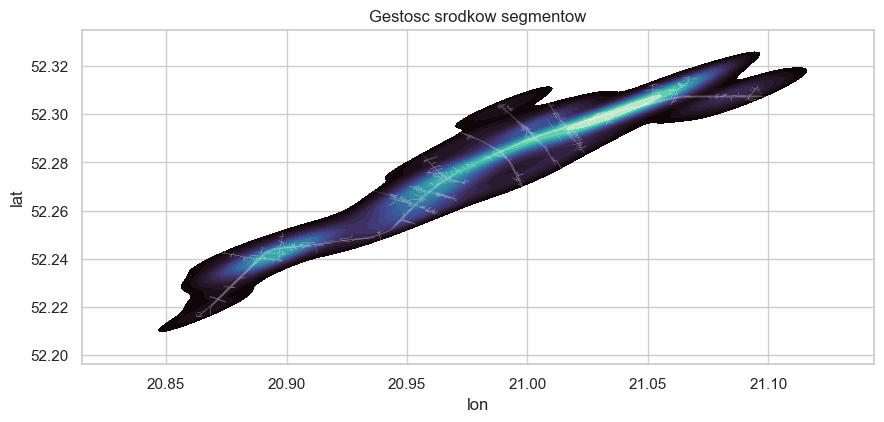

In [23]:
segments_projected = segment_speed_gdf.to_crs(epsg=2180)
segment_points = segments_projected.copy()
segment_points["center"] = segment_points.geometry.centroid
segment_points = segment_points.set_geometry("center").to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(9, 8))
sns.kdeplot(
    x=segment_points.geometry.x,
    y=segment_points.geometry.y,
    fill=True,
    levels=20,
    thresh=0.05,
    cmap="mako",
    ax=ax,
)
segment_speed_gdf.plot(ax=ax, color="white", linewidth=0.25, alpha=0.4)
ax.set_title("Gestosc srodkow segmentow")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal")
plt.tight_layout()


### Mapa godzinowa ze sliderem

Sama predkosc nie jest tym samym co natezenie ruchu. W tych danych nie mamy liczby pojazdow, wiec nie mierzymy prawdziwej intensywnosci/ruchu w sensie wolumenu. Mozemy natomiast pokazac przyblizone zatloczenie: im bardziej predkosc w danej godzinie spada wzgledem typowej predkosci danego segmentu, tym bardziej czerwony odcinek.

Przyjmujemy prosta metryke: `congestion = 1 - avg_speed_hour / reference_speed`, gdzie `reference_speed` to 90 percentyl predkosci segmentu w analizowanym dniu. Zielony oznacza plynny ruch, czerwony mocne spowolnienie.

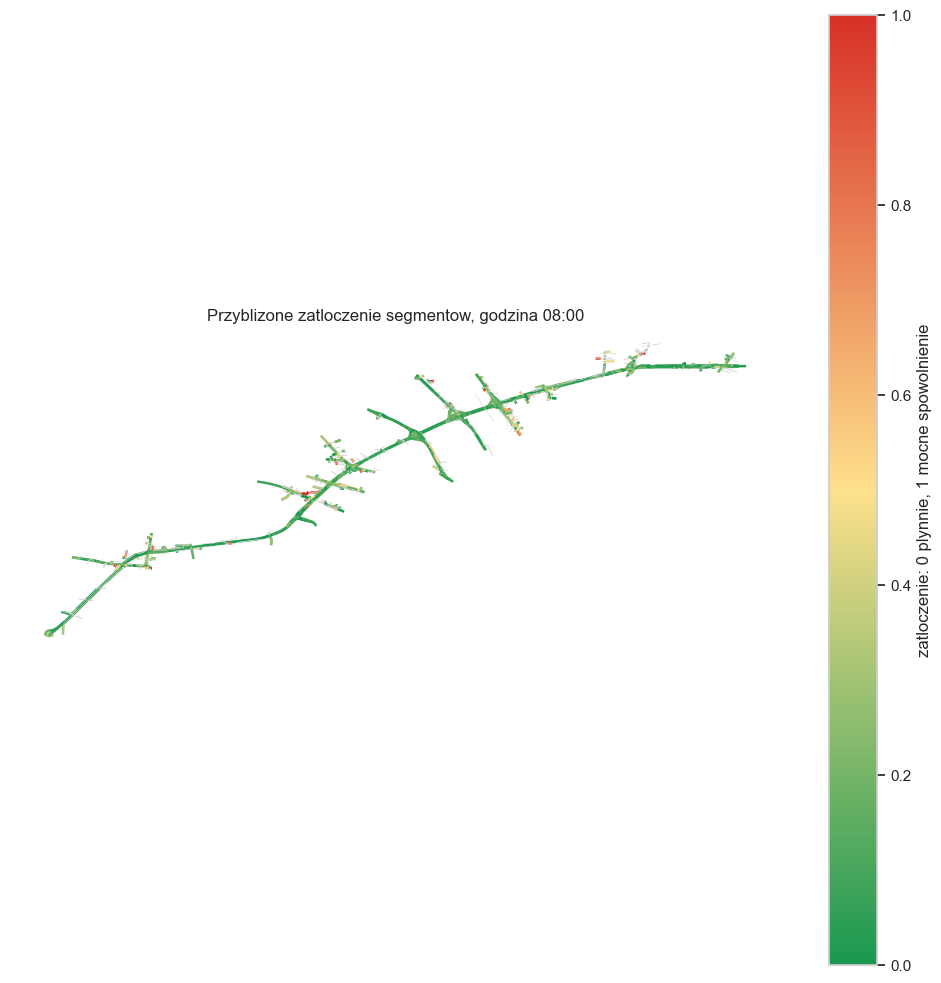

interactive(children=(IntSlider(value=8, continuous_update=False, description='godzina', max=23), Output()), _…

<function __main__.plot_traffic_hour(hour: int)>

In [30]:
from ipywidgets import IntSlider, interact

segment_hour_speed = (
    df.groupby(["segment_id", "hour"], as_index=False)
    .agg(avg_speed_hour=("avg_speed", "mean"), observations=("avg_speed", "size"))
    .merge(reference_speed, on="segment_id", how="left")
)

segment_hour_speed["speed_ratio"] = (
    segment_hour_speed["avg_speed_hour"] / segment_hour_speed["reference_speed"]
).replace([np.inf, -np.inf], np.nan)
segment_hour_speed["congestion"] = (1 - segment_hour_speed["speed_ratio"]).clip(lower=0, upper=1)

available_hours = sorted(segment_hour_speed["hour"].dropna().unique())

def plot_traffic_hour(hour: int):
    hour_gdf = segments_gdf.merge(
        segment_hour_speed[segment_hour_speed["hour"] == hour],
        on="segment_id",
        how="left",
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    hour_gdf.plot(
        column="congestion",
        ax=ax,
        linewidth=1.8,
        cmap=traffic_cmap,
        vmin=0,
        vmax=1,
        legend=True,
        legend_kwds={"label": "zatloczenie: 0 plynnie, 1 mocne spowolnienie"},
        missing_kwds={"color": "lightgrey", "linewidth": 0.4},
    )
    ax.set_title(f"Przyblizone zatloczenie segmentow, godzina {hour:02d}:00")
    ax.set_axis_off()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

interact(
    plot_traffic_hour,
    hour=IntSlider(
        value=int(available_hours[min(8, len(available_hours) - 1)]),
        min=int(min(available_hours)),
        max=int(max(available_hours)),
        step=1,
        description="godzina",
        continuous_update=False,
    ),
)


### Interaktywna mapa Folium

Ta mapa jest agregacja dla calego dnia: pokazuje typowe dzienne spowolnienie segmentu, a nie konkretna godzine. Wykorzystuje mediane predkosci z dnia porownana z predkoscia referencyjna segmentu. Po uruchomieniu komorki mapa zapisze sie do `warsaw_segments_traffic_map.html`.

In [29]:
import branca.colormap as cm
import folium

map_center_points = segment_traffic_gdf.to_crs(epsg=2180).geometry.centroid.to_crs(epsg=4326)
map_center = [map_center_points.y.mean(), map_center_points.x.mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles="CartoDB positron")

colormap = cm.LinearColormap(["#1a9850", "#fee08b", "#d73027"], vmin=0, vmax=1)
colormap.caption = "Przyblizone zatloczenie: zielony plynnie, czerwony spowolnienie"

for _, row in segment_traffic_gdf.iterrows():
    coords = [(lat, lon) for lon, lat in row.geometry.coords]
    congestion = row["daily_congestion"]
    color = colormap(float(congestion)) if pd.notna(congestion) else "#999999"
    folium.PolyLine(
        locations=coords,
        color=color,
        weight=3,
        opacity=0.85,
        tooltip=(
            f"segment_id: {row.segment_id}<br>"
            f"zatloczenie dzienne: {row.daily_congestion:.2f}<br>"
            f"mediana predkosci: {row.avg_speed_median:.1f}<br>"
            f"predkosc referencyjna: {row.reference_speed:.1f}<br>"
            f"obserwacje: {row.observations}"
        ),
    ).add_to(m)

colormap.add_to(m)
MAP_FILE = Path("warsaw_segments_traffic_map.html")
m.save(MAP_FILE)
m


## 11. Kierunki dalszej analizy mapowej

- Wybrac precyzyjnie segmenty nalezace do S8, np. przez bbox, reczna liste `segment_id` albo przeciecie z geometria drogi.
- Porownac mapy godzinowe dla dni roboczych i weekendow po wczytaniu wielu plikow dziennych.
- Zbudowac metryke spowolnienia: np. predkosc w danej godzinie wzgledem nocnej lub wzgledem 90 percentyla danego segmentu.
- Dodac interaktywne filtrowanie po godzinie, jezeli notebook bedzie uzywany prezentacyjnie.

## 12. Wnioski startowe do uzupelnienia po uruchomieniu notebooka

- Dane sa zorganizowane jako pomiary predkosci dla segmentow drogowych w kolejnych momentach dnia.
- Kluczowe pole identyfikacyjne to `segment_id`, a geometria segmentu jest zapisana jako WKT.
- Pierwszy plik dzienny zawiera dane dla jednego dnia, ale nie kazdy segment musi wystepowac w kazdym znaczniku czasu.
- Warto osobno potraktowac obserwacje z `avg_speed == 0`, bo moga oznaczac bardzo silne spowolnienie albo specyficzny sposob raportowania danych.
- Nastepny krok: porownac kilka dni naraz, sprawdzic dni robocze vs weekendy i wybrac segmenty lezace dokladnie na analizowanym fragmencie S8.